
# INFO376 [Lec12]: Practical Collaborative Filtering with Libraries

This notebook demonstrates **User-kNN**  and **Matrix Factorization (SVD)** using built-in libraries:
- [`scikit-learn`](https://scikit-learn.org) for cosine similarity & nearest neighbors.
- [`Surprise`](https://surprise.readthedocs.io) for scalable recommender algorithms.

We’ll use the same **hand-crafted ratings** dataset from our conceptual notebook.


In [1]:

import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt



## 1. Ratings Dataset


In [2]:

users = ["Alice", "Ben", "Cara", "Dan", "Eva"]
artists = ["Taylor Swift", "Eric Clapton", "Beyonce", "Black Pink", "Coldplay", "John Lennon", "The Beatles"]

data = [
    [5, 4, np.nan, np.nan, 4, 4, 1],
    [4, np.nan, 1, np.nan, 3, np.nan, 2],
    [np.nan, 2, 5, 2, np.nan, 2, 5],
    [3, 3, np.nan, 1, 4, 4, np.nan],
    [np.nan, np.nan, 4, 3, 1, 2, 1],
]
R = pd.DataFrame(data, index=users, columns=artists)
R


,Taylor Swift,Eric Clapton,Beyonce,Black Pink,Coldplay,John Lennon,The Beatles
Alice,5.0,4.0,NaN,NaN,4.0,4.0,1.0
Ben,4.0,NaN,1.0,NaN,3.0,NaN,2.0
Cara,NaN,2.0,5.0,2.0,NaN,2.0,5.0
Dan,3.0,3.0,NaN,1.0,4.0,4.0,NaN
Eva,NaN,NaN,4.0,3.0,1.0,2.0,1.0



## 2. Using scikit-learn for Cosine Similarity

We'll fill missing values with user averages (simple imputation),  
then compute **user–user** and **item–item** similarity matrices.


In [5]:
# Handle missing ratings by imputing user means 
imputer = SimpleImputer(strategy="mean")
R_filled = pd.DataFrame(imputer.fit_transform(R), index=R.index, columns=R.columns)

In [6]:
# Compute cosine similarity between users
user_sim = pd.DataFrame(cosine_similarity(R_filled), index=R.index, columns=R.index)
user_sim

,Alice,Ben,Cara,Dan,Eva
Alice,1.000000,0.959770,0.836653,0.961127,0.910702
Ben,0.959770,1.000000,0.832581,0.927777,0.852437
Cara,0.836653,0.832581,1.000000,0.888418,0.859602
Dan,0.961127,0.927777,0.888418,1.000000,0.841039
Eva,0.910702,0.852437,0.859602,0.841039,1.000000


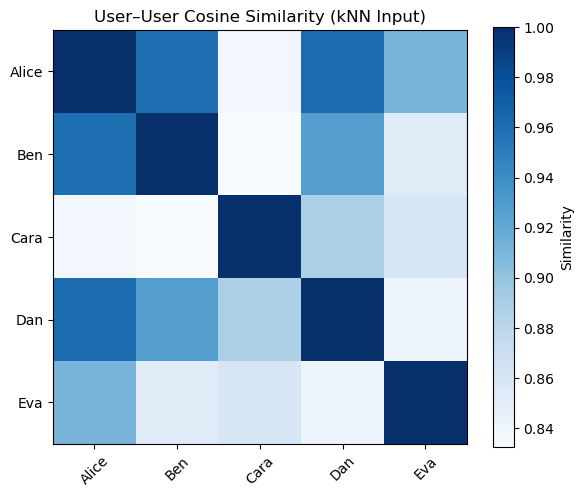

In [7]:
# Visualize user–user similarity 
plt.figure(figsize=(6, 5))
plt.imshow(user_sim, cmap="Blues", interpolation="nearest")
plt.xticks(range(len(users)), users, rotation=45)
plt.yticks(range(len(users)), users)
plt.title("User–User Cosine Similarity (kNN Input)")
plt.colorbar(label="Similarity")
plt.tight_layout()
plt.show()

In [8]:

# Fit a NearestNeighbors model to find top similar users
knn = NearestNeighbors(metric="cosine", algorithm="brute")
knn.fit(R_filled)

NearestNeighbors(algorithm='brute', metric='cosine')

In [10]:
# Example: find top 3 nearest users for each person
k = 3
for user in users:
    user_vec = [R_filled.loc[user]]
    distances, indices = knn.kneighbors(user_vec, n_neighbors=k+1)  # +1 includes self
    print(f"\nTop {k} similar users to {user}:")
    for idx, dist in zip(indices[0][1:], distances[0][1:]):  # skip self
        print(f"  {users[idx]} (similarity = {1 - dist:.3f})")



Top 3 similar users to Alice:
  Dan (similarity = 0.961)
  Ben (similarity = 0.960)
  Eva (similarity = 0.911)

Top 3 similar users to Ben:
  Alice (similarity = 0.960)
  Dan (similarity = 0.928)
  Eva (similarity = 0.852)

Top 3 similar users to Cara:
  Dan (similarity = 0.888)
  Eva (similarity = 0.860)
  Alice (similarity = 0.837)

Top 3 similar users to Dan:
  Alice (similarity = 0.961)
  Ben (similarity = 0.928)
  Cara (similarity = 0.888)

Top 3 similar users to Eva:
  Alice (similarity = 0.911)
  Cara (similarity = 0.860)
  Ben (similarity = 0.852)


/opt/conda/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(


In [13]:
#  Predict missing ratings using weighted average of neighbors

# We'll create a copy of the original rating matrix.
# Missing values (NaN) will be replaced with predictions for each user–item pair.
R_pred = R.copy()

# Iterate over each user 'u' (row in the matrix)
for u in range(len(users)):
    # Find the k nearest neighbors for this user
    # kneighbors() returns:
    #   - 'dists': distances between user 'u' and each of its k+1 nearest users
    #   - 'idxs':  indices of those neighbors in the matrix
    # The first neighbor is always the user themselves (distance = 0), so we skip it.
    dists, idxs = knn.kneighbors([R_filled.iloc[u]], n_neighbors=k+1)

    # Convert cosine *distance* to *similarity* (since cosine distance = 1 - cosine similarity)
    print(sims, neigh_idx)

    # For each item (column), estimate the rating if missing
    for i in range(len(artists)):
        if np.isnan(R.iloc[u, i]):  # only predict where the user hasn't rated
            # Extract the neighbor users' ratings for this artist
            neighbor_ratings = R_filled.iloc[neigh_idx, i]

            # Compute a weighted average:
            #   r̂_ui = (Σ_v sim(u,v) * r_vi) / (Σ_v |sim(u,v)|)
            if np.sum(sims) > 0:
                R_pred.iloc[u, i] = np.dot(sims, neighbor_ratings) / np.sum(sims)
R_pred


[0.91070162 0.85960238 0.85243671] [0 2 1]
[0.91070162 0.85960238 0.85243671] [0 2 1]
[0.91070162 0.85960238 0.85243671] [0 2 1]
[0.91070162 0.85960238 0.85243671] [0 2 1]
[0.91070162 0.85960238 0.85243671] [0 2 1]


/opt/conda/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(


,Taylor Swift,Eric Clapton,Beyonce,Black Pink,Coldplay,John Lennon,The Beatles
Alice,5.000000,4.000000,3.121209,2.0,4.000000,4.000000,1.000000
Ben,4.000000,3.019483,1.000000,2.0,3.000000,3.019483,2.000000
Cara,4.347233,2.000000,5.000000,2.0,3.347233,2.000000,5.000000
Dan,3.000000,3.000000,3.121209,1.0,4.000000,4.000000,2.636016
Eva,4.347233,3.019483,4.000000,3.0,1.000000,2.000000,1.000000


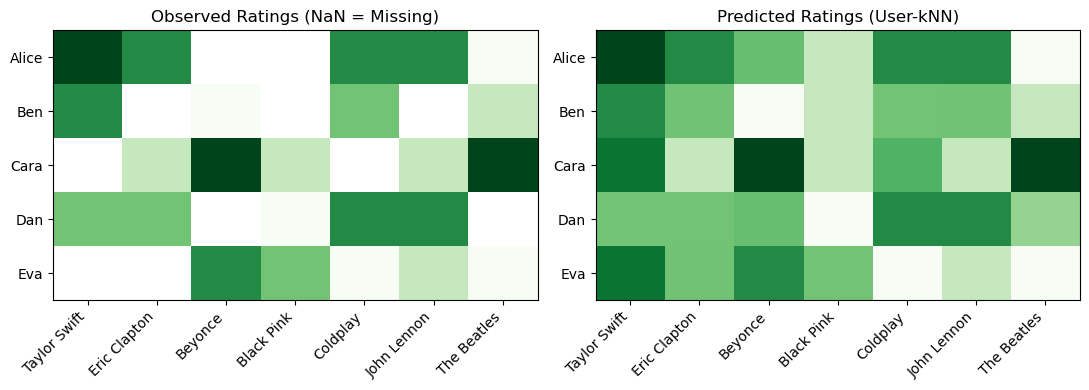

In [14]:
# --- Step 7. Visualize observed vs predicted matrices ---
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].imshow(np.nan_to_num(R.values, nan=np.nan), cmap="Greens", aspect="auto")
ax[0].set_title("Observed Ratings (NaN = Missing)")
ax[0].set_xticks(range(len(artists)))
ax[0].set_xticklabels(artists, rotation=45, ha="right")
ax[0].set_yticks(range(len(users)))
ax[0].set_yticklabels(users)

ax[1].imshow(R_pred.values, cmap="Greens", aspect="auto")
ax[1].set_title("Predicted Ratings (User-kNN)")
ax[1].set_xticks(range(len(artists)))
ax[1].set_xticklabels(artists, rotation=45, ha="right")
ax[1].set_yticks(range(len(users)))
ax[1].set_yticklabels(users)
plt.tight_layout()
plt.show()


In [15]:
# --- Step 8. Print top recommendations per user ---
def topn_unseen(original_R, predicted_R, user, N=3):
    mask = original_R.loc[user].isna()
    preds = predicted_R.loc[user, mask].sort_values(ascending=False)
    return preds.head(N)

print("\n=== Top-N Recommendations per User (User-kNN) ===")
for user in users:
    recs = topn_unseen(R, R_pred, user)
    print(f"\n{user}:")
    for item, score in recs.items():
        print(f"  {item:15s} → predicted rating {score:.2f}")


=== Top-N Recommendations per User (User-kNN) ===

Alice:
  Beyonce         → predicted rating 3.12
  Black Pink      → predicted rating 2.00

Ben:
  Eric Clapton    → predicted rating 3.02
  John Lennon     → predicted rating 3.02
  Black Pink      → predicted rating 2.00

Cara:
  Taylor Swift    → predicted rating 4.35
  Coldplay        → predicted rating 3.35

Dan:
  Beyonce         → predicted rating 3.12
  The Beatles     → predicted rating 2.64

Eva:
  Taylor Swift    → predicted rating 4.35
  Eric Clapton    → predicted rating 3.02



## 5. Matrix Factorization (MF) with SGD

We learn low‑rank embeddings for users (**P**) and items (**Q**) by minimizing squared error only on **observed** ratings:  
$$ \mathcal{L} = \sum_{(u,i)\in\Omega} (r_{ui} - p_u^\top q_i)^2 + \lambda(\|p_u\|^2 + \|q_i\|^2) $$  
We implement a simple 2‑D model (\(k=2\)) so that embeddings can be **visualized**.


In [16]:
# Prepare observed triplets
obs = []
for u_idx, u in enumerate(R.index):
    for i_idx, i in enumerate(R.columns):
        val = R.loc[u, i]
        if not np.isnan(val):
            obs.append((u_idx, i_idx, float(val)))

In [17]:
m, n = len(R.index), len(R.columns)
k = 2
np.random.seed(7)
P = 0.5 * np.random.randn(m, k)
Q = 0.5 * np.random.randn(n, k)

eta = 0.05   # learning rate
lam = 0.02   # regularization
epochs = 30

losses = []

In [18]:
for ep in range(epochs):
    sse = 0.0  # Track the total squared error for this epoch

    # Randomize the order of observed (user, item, rating) triples.
    # This ensures the gradient updates don't get biased by order.
    np.random.shuffle(obs)

    # For each observed rating (u, i, r_ui), update P[u] and Q[i]
    for (u, i, r_ui) in obs:
        # 1. Forward pass: predict rating by dot product of user & item embeddings
        #    r̂_ui = p_u · q_i
        pred = float(P[u].dot(Q[i]))

        # 2. Compute the prediction error: e_ui = r_ui - r̂_ui
        e = r_ui - pred

        # Accumulate squared error to monitor convergence
        sse += e**2

        # 3.  Gradient Descent Update (with L2 regularization):
        #    p_u ← p_u + η * (e_ui * q_i − λ * p_u)
        #    q_i ← q_i + η * (e_ui * p_u − λ * q_i)
        #
        #    where:
        #       η = learning rate (step size)
        #       λ = regularization coefficient (prevents overfitting)
        #
        # Important: when updating Q[i], use the *old* P[u] value (Pu_old)
        # to avoid interference between simultaneous updates.
        Pu_old = P[u].copy()
        P[u] += eta * (e * Q[i] - lam * P[u])
        Q[i] += eta * (e * Pu_old - lam * Q[i])

    # Compute Mean Squared Error for this epoch and log it.
    # Helps visualize convergence of the SGD process.
    losses.append(sse / len(obs))


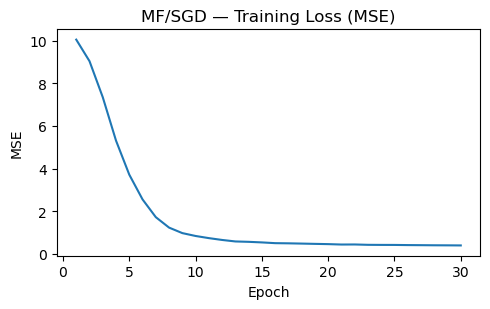

(array([[ 1.47313374, -1.64890161],
        [ 1.35470058, -1.19570347],
        [ 2.3736083 ,  0.85139193],
        [ 0.59981963, -1.89045541],
        [ 1.71264682, -0.048784  ]]),
 array([[ 1.88369021, -1.12873026],
        [ 1.27523174, -1.20220239],
        [ 1.86035302,  0.88651883],
        [ 1.19286901, -0.25083493],
        [ 0.57193585, -1.87137169],
        [ 1.25297059, -1.44690565],
        [ 1.58578626,  0.70224796]]))

In [19]:





plt.figure(figsize=(5,3.2))
plt.plot(range(1, epochs+1), losses)
plt.title("MF/SGD — Training Loss (MSE)")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.tight_layout()
plt.show()

P, Q


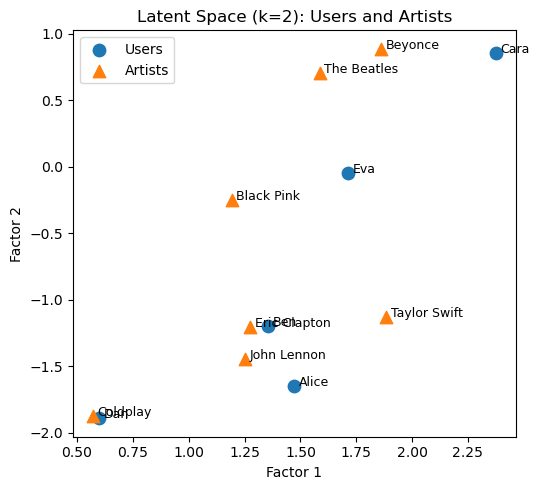

,Taylor Swift,Eric Clapton,Beyonce,Black Pink,Coldplay,John Lennon,The Beatles
Alice,4.64,3.86,1.28,2.17,3.93,4.23,1.18
Ben,3.90,3.17,1.46,1.92,3.01,3.43,1.31
Cara,3.51,2.00,5.17,2.62,-0.24,1.74,4.36
Dan,3.26,3.04,-0.56,1.19,3.88,3.49,-0.38
Eva,3.28,2.24,3.14,2.06,1.07,2.22,2.68


In [25]:

# Visualize 2D embeddings (users vs items)
plt.figure(figsize=(5.5,5))
plt.scatter(P[:,0], P[:,1], s=80, label="Users")
plt.scatter(Q[:,0], Q[:,1], s=80, marker='^', label="Artists")
for (x,y), name in zip(P, R.index):
    plt.text(x+0.02, y, name, fontsize=9)
for (x,y), name in zip(Q, R.columns):
    plt.text(x+0.02, y, name, fontsize=9)
plt.title("Latent Space (k=2): Users and Artists")
plt.xlabel("Factor 1"); plt.ylabel("Factor 2")
plt.legend()
plt.tight_layout()
plt.show()

# Predicted full matrix
R_hat = P.dot(Q.T)
R_pred = pd.DataFrame(R_hat, index=R.index, columns=R.columns)
R_pred.round(2)


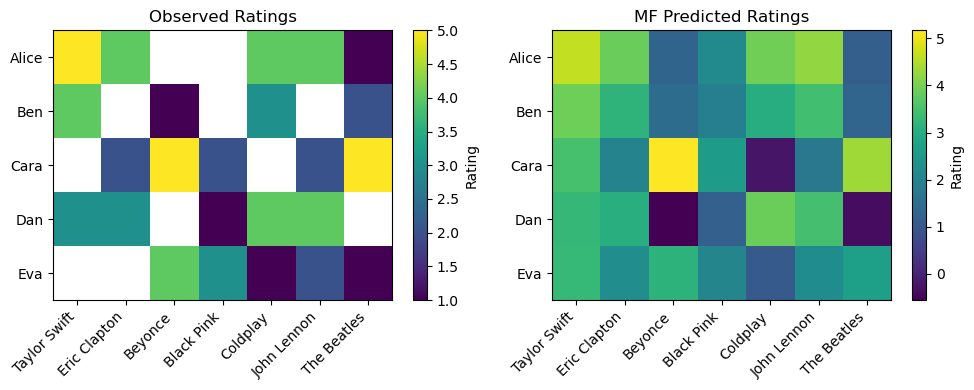

In [26]:

# Observed vs Predicted heatmaps
fig = plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(np.nan_to_num(R.values, nan=np.nan), aspect='auto')
plt.xticks(range(len(R.columns)), R.columns, rotation=45, ha='right')
plt.yticks(range(len(R.index)), R.index)
plt.title("Observed Ratings")
plt.colorbar(label="Rating")

plt.subplot(1,2,2)
plt.imshow(R_pred.values, aspect='auto')
plt.xticks(range(len(R.columns)), R.columns, rotation=45, ha='right')
plt.yticks(range(len(R.index)), R.index)
plt.title("MF Predicted Ratings")
plt.colorbar(label="Rating")

plt.tight_layout()
plt.show()



## 4. Reflection

| Method | Pros | Cons |
|--------|------|------|
| **User-kNN** | Intuitive, explainable | Sparse overlap → unstable |
| **Item-kNN** | Scalable, interpretable | Needs co-listens |
| **SVD (MF)** | Generalizes, compact latent space | Needs tuning, harder to explain |

> **In practice:** Most modern recommenders combine SVD-style latent models with lightweight kNN components for interpretability and cold-start handling.
